# RACE Dataset — Exploratory Data Analysis
**Intelligent Reading Comprehension & Quiz Generation System**
NUCES FAST Islamabad · BS (CS) Spring 2026

---
**Structure**
1. Setup & Loading
2. Basic Integrity Checks
3. Distribution Plots (labels, article/question lengths, question types, option lengths)
4. Cross-Split Summary (train / dev / test consistency)
5. Anomaly & Edge-Case Audit
6. Option Feature Analysis (overlap, recoverability, correct vs incorrect)
7. Passage-level Statistics & Content-Word Frequency
8. Key Insights for Modeling


## 1. Setup & Loading

In [24]:
# ── Mount drive (Colab) ──────────────────────────────────────────────────────
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")
DATA_DIR = Path("/content/drive/MyDrive/dataset")
assert (DATA_DIR / "train.csv").exists(), f"Not found: {DATA_DIR / 'train.csv'}"
print("Using:", DATA_DIR.resolve())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: /content/drive/MyDrive/dataset


In [25]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

OPTION_COLS = ["A", "B", "C", "D"]


In [26]:
train = pd.read_csv(DATA_DIR / "train.csv")
dev   = pd.read_csv(DATA_DIR / "dev.csv")
test  = pd.read_csv(DATA_DIR / "test.csv")

# Drop unnamed index columns that pandas sometimes adds on re-save
for df in (train, dev, test):
    df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")],
            inplace=True, errors="ignore")

for name, df in [("train", train), ("dev", dev), ("test", test)]:
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    display(df.head(2))



=== TRAIN ===
Shape: (70292, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,high7653.txt,"""Teenager"" is the new term being used in the U...",Which is true about kids in the past?,They used to have more money to spend.,They couldn't influence their parents.,They preferred to wear brighter clothes.,They looked older than their age.,C
1,middle4509.txt,Mobile phone technology is developing rapidly....,We can learn from the passage that _ .,the Packet has five touch screens with differe...,the Cobalto has been used in the phone market ...,"the Paper Phone is easy to break, but difficul...",talking on the Human-body phone makes people a...,A



=== DEV ===
Shape: (8786, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,high1054.txt,Use your American Express Card to enjoy one-da...,We learn from the text that Martha Graham is ...,a dancer,a glassblower,a painter,a photographer,A
1,high23455.txt,Japanese workers who run secretly out of the o...,The system Partout can't tell that _ .,the person is running,the person is walking,the person is stopping,the person is speaking,D



=== TEST ===
Shape: (8788, 8)
Columns: ['id', 'article', 'question', 'A', 'B', 'C', 'D', 'answer']


,id,article,question,A,B,C,D,answer
0,high22604.txt,Every day from the time we wake up until the t...,When faced with an incredible or fantastic cla...,Ask questions and look for proof.,Ignore the information and its source.,Change the subject immediately.,Try to consult an expert who knows the truth.,A
1,high20644.txt,The huge thirst for jobs in the civil service ...,Which of the following could NOT be the reason...,The stable income.,Good heath care.,Practical profits.,Low work stress level.,B


## 2. Basic Integrity Checks

In [27]:
cols_needed = ["article", "question", "A", "B", "C", "D", "answer"]

print("── Null counts ──")
for name, df in [("train", train), ("dev", dev), ("test", test)]:
    print(f"\n{name}:\n{df[cols_needed].isnull().sum().to_string()}")

print("\n── Invalid answer labels ──")
allowed = {"A", "B", "C", "D"}
for name, df in [("train", train), ("dev", dev), ("test", test)]:
    bad = sorted(df.loc[~df["answer"].isin(allowed), "answer"].dropna().unique().tolist())
    print(f"{name}: {bad if bad else 'none — all valid'}")


── Null counts ──

train:
article     0
question    0
A           3
B           0
C           1
D           6
answer      0

dev:
article     0
question    0
A           0
B           0
C           0
D           1
answer      0

test:
article     0
question    0
A           1
B           0
C           0
D           2
answer      0

── Invalid answer labels ──
train: none — all valid
dev: none — all valid
test: none — all valid


## 3. Helper Functions & Derived Columns

In [28]:
def word_count(text):
    return 0 if pd.isna(text) else len(str(text).split())

def sentence_count(text):
    return len(re.split(r"(?<=[.!?])\s+", str(text).strip()))

def question_type(q):
    if pd.isna(q):
        return "Other"
    first = str(q).strip().split(maxsplit=1)[0]
    key = first.strip(":_\"'\u201c\u2018?!").lower().capitalize()
    return key if key in {"Who", "What", "Where", "When", "Why", "How", "Which"} else "Other"

def tokenize(text):
    return set(re.findall(r"\b\w+\b", str(text).lower()))

# Add derived columns to train (used for most plots)
train = train.copy()
train["_wc_article"]   = train["article"].map(word_count)
train["_wc_question"]  = train["question"].map(word_count)
train["_sent_count"]   = train["article"].map(sentence_count)
train["_qtype"]        = train["question"].map(question_type)


## 4. Distribution Plots

### 4.1 Answer Label Distribution — all splits
Checking for class imbalance across train / dev / test.


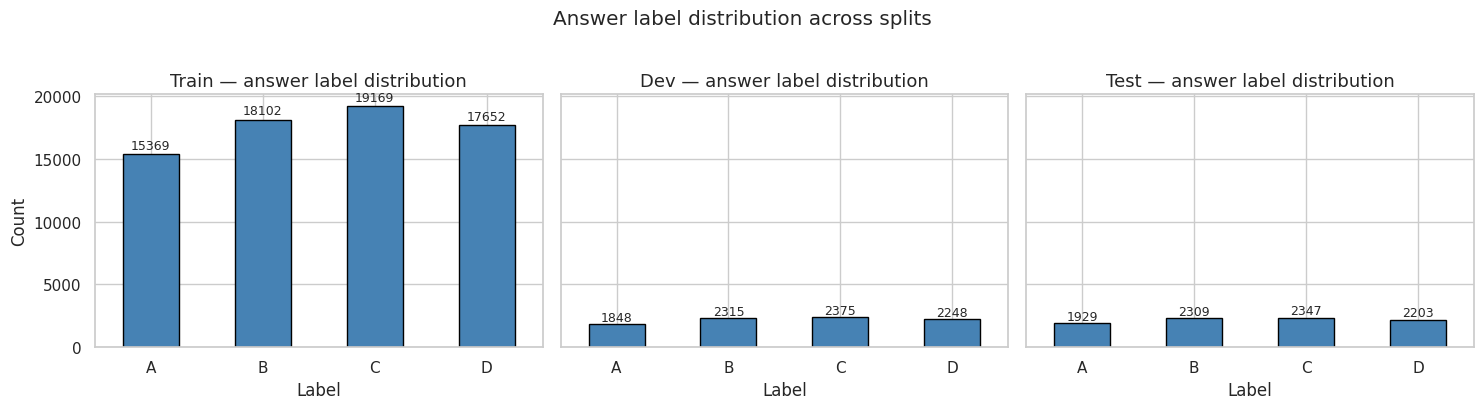

Train proportions:
answer
A    0.2186
B    0.2575
C    0.2727
D    0.2511
Name: count, dtype: float64


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (split_name, df) in zip(axes, [("Train", train), ("Dev", dev), ("Test", test)]):
    counts = df["answer"].value_counts().reindex(OPTION_COLS).fillna(0).astype(int)
    counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"{split_name} — answer label distribution")
    ax.set_xlabel("Label"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=0)
    ymax = counts.max()
    for i, v in enumerate(counts):
        ax.text(i, v + ymax * 0.01, str(v), ha="center", va="bottom", fontsize=9)
plt.suptitle("Answer label distribution across splits", y=1.02)
plt.tight_layout()
plt.show()

print("Train proportions:")
print((train["answer"].value_counts().reindex(OPTION_COLS) / len(train)).round(4))


### 4.2 Article Length Distribution

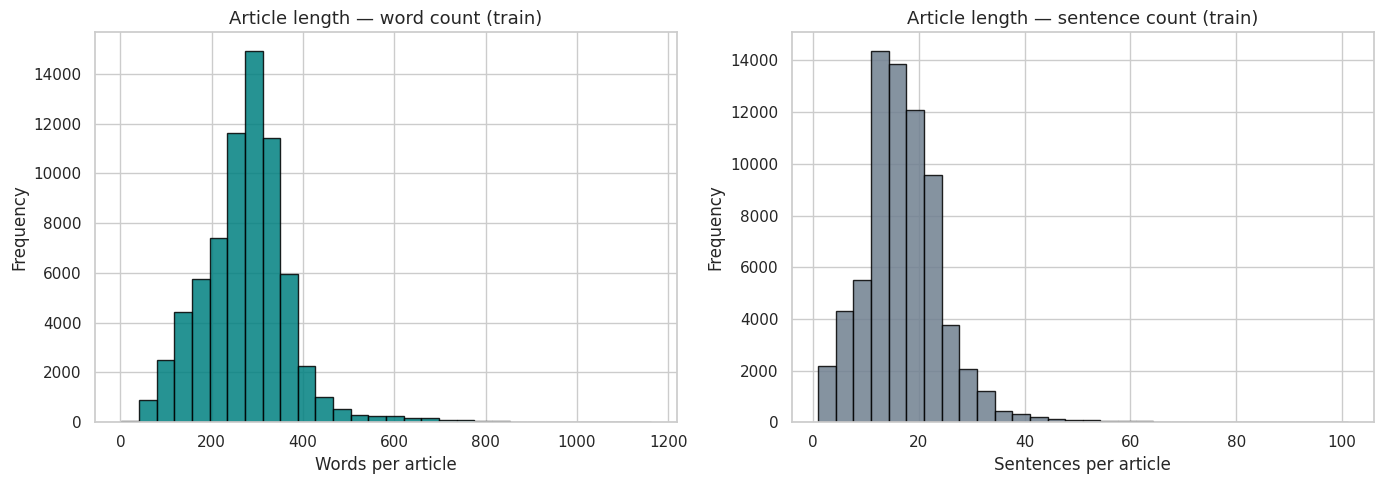

       _wc_article  _sent_count
count      70292.0      70292.0
mean         275.0         16.9
std           97.6          7.5
min            2.0          1.0
25%          217.0         12.0
50%          279.0         16.0
75%          326.0         21.0
max         1162.0        101.0


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train["_wc_article"], bins=30, color="teal", edgecolor="black", alpha=0.85)
axes[0].set_title("Article length — word count (train)")
axes[0].set_xlabel("Words per article"); axes[0].set_ylabel("Frequency")

axes[1].hist(train["_sent_count"], bins=30, color="slategray", edgecolor="black", alpha=0.85)
axes[1].set_title("Article length — sentence count (train)")
axes[1].set_xlabel("Sentences per article"); axes[1].set_ylabel("Frequency")

plt.tight_layout(); plt.show()
print(train[["_wc_article", "_sent_count"]].describe().round(1))


### 4.3 Question Length Distribution

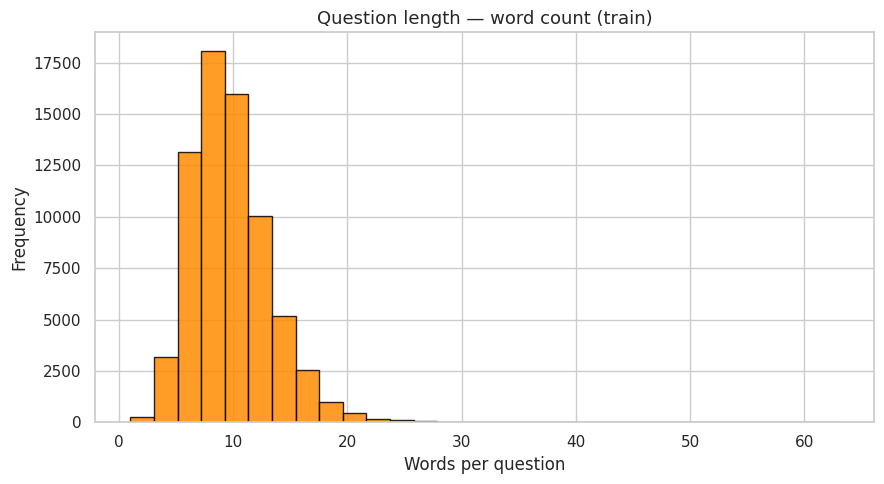

count    70292.00
mean        10.00
std          3.38
min          1.00
25%          8.00
50%         10.00
75%         12.00
max         63.00
Name: _wc_question, dtype: float64


In [31]:
plt.hist(train["_wc_question"], bins=30, color="darkorange", edgecolor="black", alpha=0.85)
plt.title("Question length — word count (train)")
plt.xlabel("Words per question"); plt.ylabel("Frequency")
plt.tight_layout(); plt.show()
print(train["_wc_question"].describe().round(2))


### 4.4 Question Type Distribution

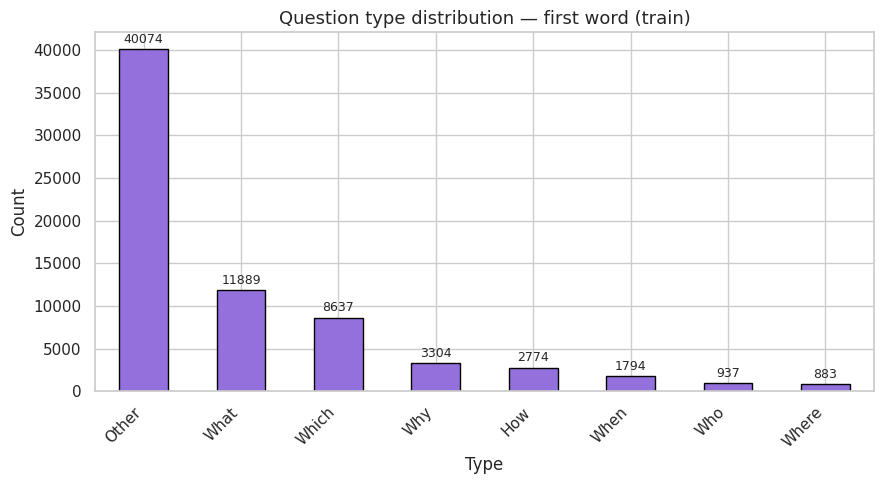

In [32]:
qt_counts = train["_qtype"].value_counts()
ax = qt_counts.plot(kind="bar", color="mediumpurple", edgecolor="black")
ax.set_title("Question type distribution — first word (train)")
ax.set_xlabel("Type"); ax.set_ylabel("Count")
qm = qt_counts.max()
for i, v in enumerate(qt_counts):
    ax.text(i, v + qm * 0.01, str(int(v)), ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


### 4.5 Answer Option Length — correct vs incorrect per slot

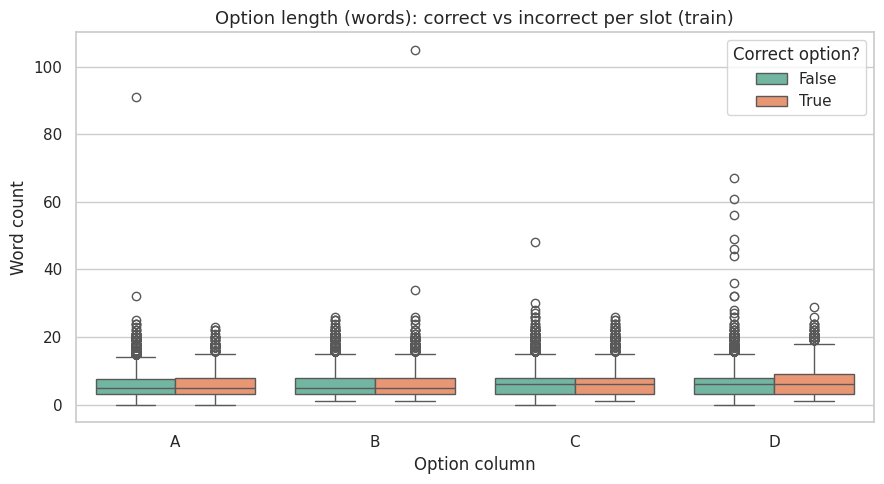

In [33]:
opt_rows = []
for _, r in train.iterrows():
    for opt in OPTION_COLS:
        opt_rows.append({"option_slot": opt, "wc": word_count(r[opt]),
                         "is_correct": opt == r["answer"]})
opt_long = pd.DataFrame(opt_rows)

sns.boxplot(data=opt_long, x="option_slot", y="wc", hue="is_correct", palette="Set2")
plt.title("Option length (words): correct vs incorrect per slot (train)")
plt.xlabel("Option column"); plt.ylabel("Word count")
plt.legend(title="Correct option?")
plt.tight_layout(); plt.show()


### 4.6 Word Cloud — train articles *(bonus)*

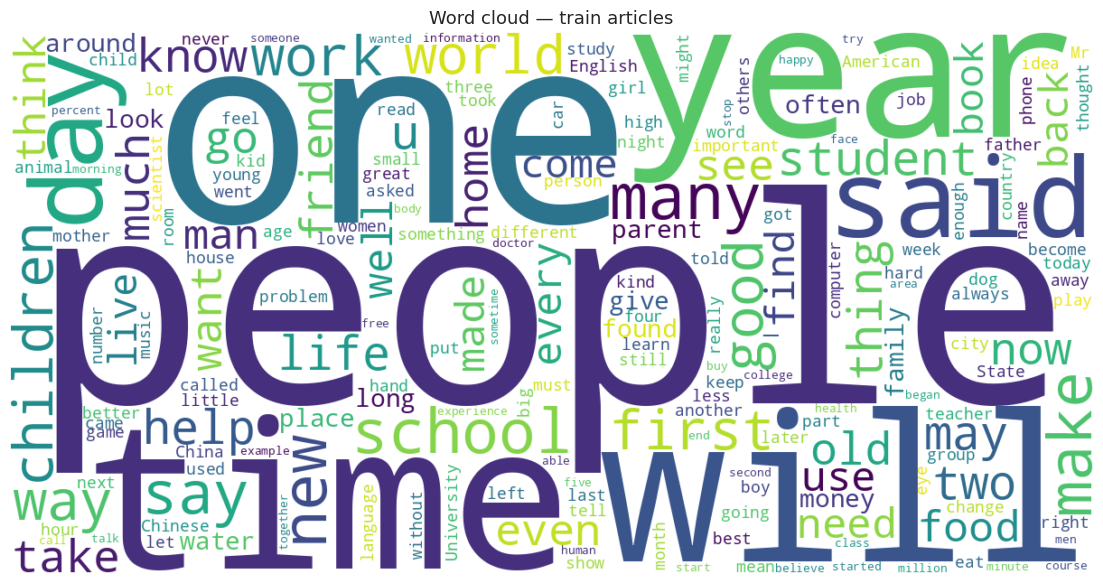

In [34]:
try:
    from wordcloud import WordCloud
    text_corpus = " ".join(train["article"].astype(str))
    wc = WordCloud(width=1200, height=600, background_color="white",
                   collocations=False).generate(text_corpus)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title("Word cloud — train articles"); plt.tight_layout(); plt.show()
except ImportError:
    print("wordcloud not installed — skip: pip install wordcloud")


## 5. Cross-Split Summary

One table showing article/question stats, vocabulary sizes, answer label counts, and
question-type counts across all three splits.  Use this to check that train/dev/test
are drawn from the same distribution.


In [35]:
split_rows = []
for split_name, df in [("train", train), ("dev", dev), ("test", test)]:
    a_wc = df["article"].map(word_count)
    q_wc = df["question"].map(word_count)
    ans  = df["answer"].value_counts().reindex(OPTION_COLS).fillna(0).astype(int)
    qt   = df["question"].map(question_type).value_counts()               .reindex(["Who","What","Where","When","Why","How","Which","Other"])               .fillna(0).astype(int)

    # questions-per-article
    if "id" in df.columns:
        qpa = len(df) / df["id"].nunique()
    else:
        qpa = float("nan")

    split_rows.append({
        "split":               split_name,
        "rows":                len(df),
        "article_wc_mean":     a_wc.mean(),
        "article_wc_median":   a_wc.median(),
        "question_wc_mean":    q_wc.mean(),
        "question_wc_median":  q_wc.median(),
        "article_vocab":       len(set(" ".join(df["article"].astype(str).str.lower()).split())),
        "question_vocab":      len(set(" ".join(df["question"].astype(str).str.lower()).split())),
        "avg_q_per_article":   round(qpa, 2),
        **{f"ans_{k}": int(ans[k]) for k in OPTION_COLS},
        **{f"qt_{k.lower()}": int(qt[k]) for k in ["Who","What","Where","When","Why","How","Which","Other"]},
    })

split_summary = pd.DataFrame(split_rows).set_index("split")
display(split_summary.round(2))


,rows,article_wc_mean,article_wc_median,question_wc_mean,question_wc_median,article_vocab,question_vocab,avg_q_per_article,ans_A,ans_B,ans_C,ans_D,qt_who,qt_what,qt_where,qt_when,qt_why,qt_how,qt_which,qt_other
split,,,,,,,,,,,,,,,,,,,,
train,70292,275.03,279.0,10.00,10.0,242606,34439,2.83,15369,18102,19169,17652,937,11889,883,1794,3304,2774,8637,40074
dev,8786,274.58,278.0,10.00,10.0,110968,9939,1.15,1848,2315,2375,2248,107,1442,94,217,431,341,1075,5079
test,8788,275.04,280.0,10.06,10.0,110863,9910,1.14,1929,2309,2347,2203,113,1509,116,236,377,335,1113,4989


## 6. Anomaly & Edge-Case Audit

Flagging degenerate rows so we know whether to drop / clamp them in preprocessing.


In [36]:
print("── Tiny articles (≤ 30 words) ──")
tiny = train.loc[train["_wc_article"] <= 30, ["id", "article", "question"]]
print(f"Count: {len(tiny)}")
display(tiny.head(5))

print("\n── Very short questions (≤ 1 word) ──")
short_q = train.loc[train["_wc_question"] <= 1, ["id", "question"]]
print(f"Count: {len(short_q)}")
display(short_q.head(5))

print("\n── Empty / missing options ──")
mask_empty = (train[OPTION_COLS].astype(str)
              .map(lambda s: len(s.split()) == 0)
              .any(axis=1))
print("Rows with ≥1 empty option:", mask_empty.sum())

print("\n── Very long options (> 30 words) ──")
long_mask = (train[OPTION_COLS].astype(str)
             .map(lambda s: len(s.split()) > 30)
             .any(axis=1))
print("Rows with ≥1 option > 30 words:", long_mask.sum())

print("\n── Sample 'Other'-type questions (likely cloze / fill-in-the-blank stems) ──")
other_qs = train.loc[train["_qtype"] == "Other", "question"].sample(10, random_state=42)
for q in other_qs:
    print("•", q)


── Tiny articles (≤ 30 words) ──
Count: 28


,id,article,question
1575,high19431.txt,One thing we love about soup is that it's easy...,How can you make the chicken soup more delicious?
6337,middle8028.txt,Passage 1,"According to the form, which of the following ..."
6586,middle5352.txt,"The Cuckoo\nIn April,\nCome he will.\nIn May,\...",What does the cuckoo do in May?
7241,middle7500.txt,Welcome to the zoo\nOpening time: ...,The zoo opens _ a week.
14284,middle7500.txt,Welcome to the zoo\nOpening time: ...,"On Tuesday,the zoo closes at _ ."



── Very short questions (≤ 1 word) ──
Count: 22


,id,question
3466,high12051.txt,.
8842,middle4598.txt,?
10319,middle4549.txt,1.
14116,high12170.txt,.
14243,high16951.txt,Weihenmayer_.



── Empty / missing options ──
Rows with ≥1 empty option: 0

── Very long options (> 30 words) ──
Rows with ≥1 option > 30 words: 11

── Sample 'Other'-type questions (likely cloze / fill-in-the-blank stems) ──
• The young visitor stayed a long time in my friend's house, didn't he?
• The player can't touch the ball with their  _  .
• We can conclude from the passage that  _  .
• You can probably read this passage   _  .
• The author of the passage tends to   _  .
• The potential readers of the text are   _  .
• Li Ming's   _   is hurt.
• Justin Biber is a   _  .
• Mr. and Mrs. Green learn a lot about ancient technology on   _  .
• The next World Cup will be held in   _  , after 2006.


## 7. Option Feature Analysis — Overlap & Recoverability

Single unified loop over all three splits.  For each (article, question, option) triple we compute:
- **article_overlap** — fraction of option words that also appear in the article  
- **question_overlap** — fraction of option words that appear in the question  
- **exact_in_article** — whether the full option string is a substring of the article  
- **exact_in_question** — same for the question  

These are also the core lexical features for Model A (answer verification) and Model B (distractor ranker).


In [37]:
feat_rows = []
for split_name, df in [("train", train), ("dev", dev), ("test", test)]:
    for _, r in df.iterrows():
        art_tok = tokenize(r["article"])
        q_tok   = tokenize(r["question"])
        art_str = str(r["article"]).lower()
        q_str   = str(r["question"]).lower()
        qt      = question_type(r["question"])
        for opt in OPTION_COLS:
            opt_str = str(r[opt]).lower()
            opt_tok = tokenize(r[opt])
            feat_rows.append({
                "split":            split_name,
                "option_slot":      opt,
                "is_correct":       opt == r["answer"],
                "qtype":            qt,
                "option_wc":        word_count(r[opt]),
                "article_overlap":  len(art_tok & opt_tok) / max(len(opt_tok), 1),
                "question_overlap": len(q_tok   & opt_tok) / max(len(opt_tok), 1),
                "exact_in_article": int(opt_str in art_str),
                "exact_in_question":int(opt_str in q_str),
            })

feat_df = pd.DataFrame(feat_rows)
print("Rows in feature table:", len(feat_df))


Rows in feature table: 351464


### 7.1 Correct vs Incorrect — summary statistics

In [38]:
ci_summary = feat_df[feat_df["split"] == "train"].groupby("is_correct").agg(
    option_wc_mean        =("option_wc",         "mean"),
    option_wc_median      =("option_wc",         "median"),
    article_overlap_mean  =("article_overlap",   "mean"),
    article_overlap_median=("article_overlap",   "median"),
    question_overlap_mean =("question_overlap",  "mean"),
    exact_in_article_rate =("exact_in_article",  "mean"),
    exact_in_question_rate=("exact_in_question", "mean"),
)
ci_summary.index = ["incorrect option", "correct option"]
display(ci_summary.round(4))


,option_wc_mean,option_wc_median,article_overlap_mean,article_overlap_median,question_overlap_mean,exact_in_article_rate,exact_in_question_rate
incorrect option,5.6399,5.0,0.6349,0.6667,0.0893,0.0758,0.0011
correct option,5.9140,6.0,0.6823,0.7333,0.0862,0.1145,0.0008


### 7.2 Overlap box-plots by slot (train)

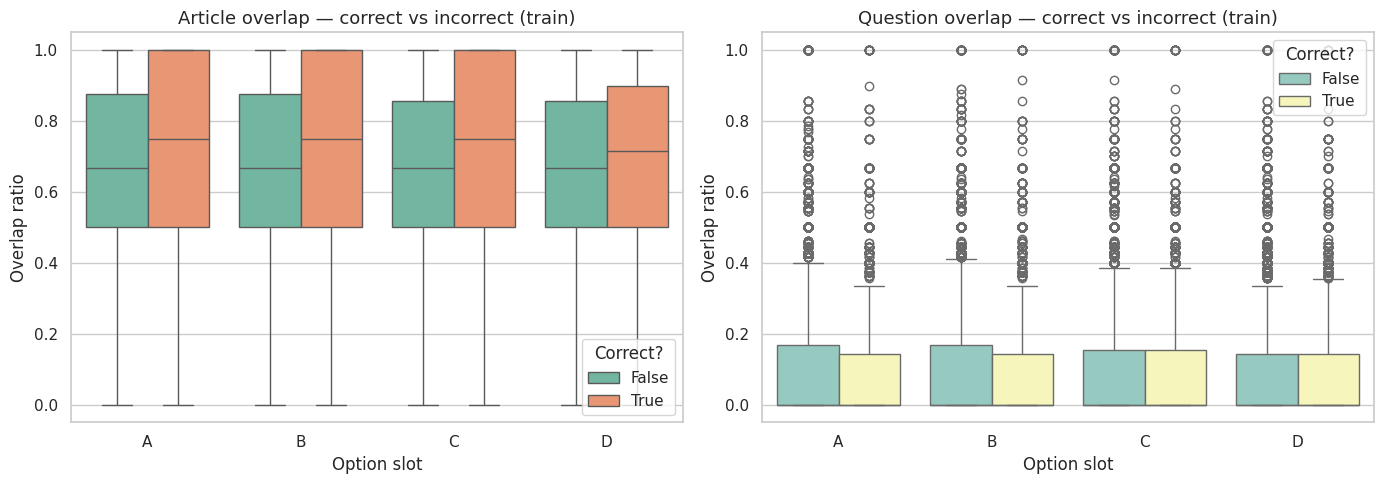

In [39]:
train_feat = feat_df[feat_df["split"] == "train"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train_feat, x="option_slot", y="article_overlap",
            hue="is_correct", ax=axes[0], palette="Set2")
axes[0].set_title("Article overlap — correct vs incorrect (train)")
axes[0].set_xlabel("Option slot"); axes[0].set_ylabel("Overlap ratio")
axes[0].legend(title="Correct?")

sns.boxplot(data=train_feat, x="option_slot", y="question_overlap",
            hue="is_correct", ax=axes[1], palette="Set3")
axes[1].set_title("Question overlap — correct vs incorrect (train)")
axes[1].set_xlabel("Option slot"); axes[1].set_ylabel("Overlap ratio")
axes[1].legend(title="Correct?")
plt.tight_layout(); plt.show()


### 7.3 Exact recoverability — across splits & question types

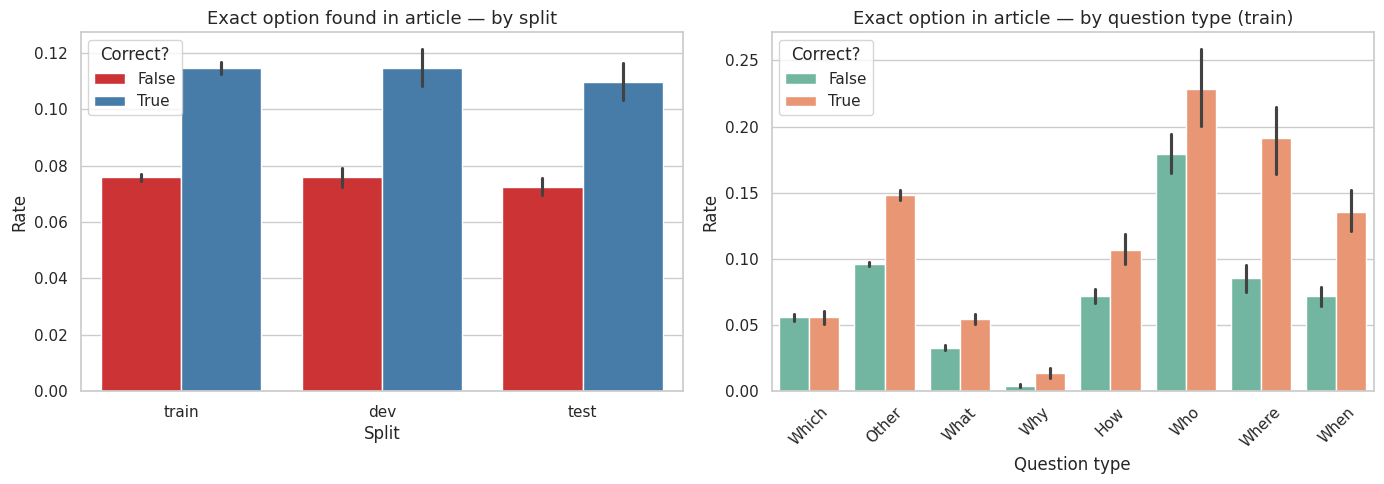

,split,is_correct,exact_in_article_rate,exact_in_question_rate,article_overlap_mean,option_wc_mean
0,dev,incorrect,0.0758,0.0009,0.6303,5.6148
1,dev,correct,0.1146,0.0008,0.6787,5.8772
2,test,incorrect,0.0726,0.0013,0.6337,5.6442
3,test,correct,0.1097,0.0008,0.6787,5.9101
4,train,incorrect,0.0758,0.0011,0.6349,5.6399
5,train,correct,0.1145,0.0008,0.6823,5.9140


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=feat_df, x="split", y="exact_in_article",
            hue="is_correct", ax=axes[0], palette="Set1")
axes[0].set_title("Exact option found in article — by split")
axes[0].set_xlabel("Split"); axes[0].set_ylabel("Rate")
axes[0].legend(title="Correct?")

sns.barplot(data=feat_df[feat_df["split"] == "train"],
            x="qtype", y="exact_in_article",
            hue="is_correct", ax=axes[1], palette="Set2")
axes[1].set_title("Exact option in article — by question type (train)")
axes[1].set_xlabel("Question type"); axes[1].set_ylabel("Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Correct?")
plt.tight_layout(); plt.show()

# Numeric summary by split
rec_split = feat_df.groupby(["split", "is_correct"]).agg(
    exact_in_article_rate =("exact_in_article",  "mean"),
    exact_in_question_rate=("exact_in_question", "mean"),
    article_overlap_mean  =("article_overlap",   "mean"),
    option_wc_mean        =("option_wc",         "mean"),
).reset_index()
rec_split["is_correct"] = rec_split["is_correct"].map({True:"correct", False:"incorrect"})
display(rec_split.round(4))


### 7.4 Correct-answer word-overlap histogram (train sample)

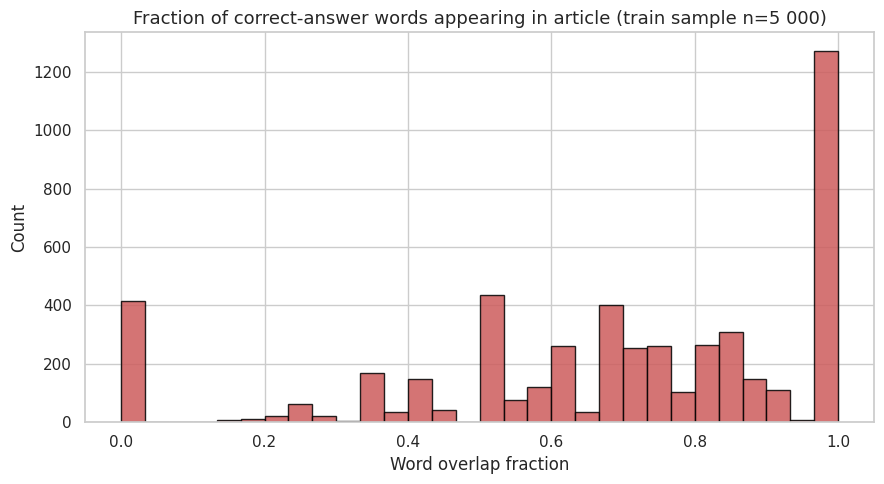

count    5000.0000
mean        0.6806
std         0.2927
min         0.0000
25%         0.5000
50%         0.7273
75%         1.0000
max         1.0000
Name: _overlap, dtype: float64


In [41]:
# How much of the correct answer is already in the article?
sample = train.sample(5000, random_state=42).copy()
sample["_overlap"] = sample.apply(
    lambda r: len(tokenize(r["article"]) & tokenize(r[r["answer"]])) /
              max(len(tokenize(r[r["answer"]])), 1),
    axis=1,
)
plt.figure(figsize=(9, 5))
plt.hist(sample["_overlap"], bins=30, color="indianred", edgecolor="black", alpha=0.85)
plt.title("Fraction of correct-answer words appearing in article (train sample n=5 000)")
plt.xlabel("Word overlap fraction"); plt.ylabel("Count")
plt.tight_layout(); plt.show()
print(sample["_overlap"].describe().round(4))


## 8. Passage-level Statistics & Content-Word Frequency

In [42]:
def summarize_series(s):
    return pd.Series({"mean": s.mean(), "median": s.median(),
                      "min": s.min(), "max": s.max(), "std": s.std()})

opt_wc_all = [word_count(train.loc[i, opt])
              for i in train.index for opt in OPTION_COLS]
opt_wc_series = pd.Series(opt_wc_all)

vocab_train = len(set(" ".join(train["article"].astype(str).str.lower()).split()))

summary_df = pd.DataFrame({
    "article_word_count":      summarize_series(train["_wc_article"]),
    "question_word_count":     summarize_series(train["_wc_question"]),
    "answer_option_word_count":summarize_series(opt_wc_series),
})
summary_df.loc["vocab_unique_words"] = {
    "article_word_count": vocab_train,
    "question_word_count": float("nan"),
    "answer_option_word_count": float("nan"),
}
display(summary_df.round(2))


,article_word_count,question_word_count,answer_option_word_count
mean,275.03,10.00,5.71
median,279.00,10.00,5.00
min,2.00,1.00,0.00
max,1162.00,63.00,105.00
std,97.64,3.38,3.45
vocab_unique_words,242606.00,NaN,NaN


In [43]:
# Questions per article (if 'id' column present)
if "id" in train.columns:
    print("Unique article ids:", train["id"].nunique())
    print("Total rows:", len(train))
    print("Avg questions per article:", round(len(train) / train["id"].nunique(), 2))
    per_article = train.groupby("id").size()
    print(per_article.describe().round(2))


Unique article ids: 24807
Total rows: 70292
Avg questions per article: 2.83
count    24807.00
mean         2.83
std          1.04
min          1.00
25%          2.00
50%          3.00
75%          4.00
max          6.00
dtype: float64


,word,count
0,you,179957
1,he,138495
2,they,123846
3,have,106780
4,his,83437
5,people,83346
6,can,80342
7,their,79537
8,not,77693
9,we,77690


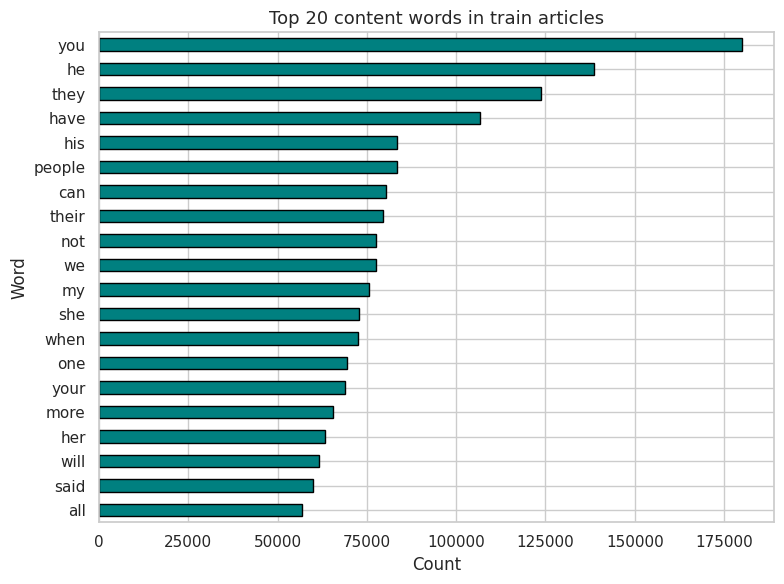

In [44]:
STOPWORDS = {
    "the","a","an","and","or","of","to","in","on","for","with","at","by","from",
    "is","was","were","are","be","been","being","it","this","that","these","those",
    "as","but","if","into","about","over","after","before","during","through","than",
}
word_counts = Counter()
for text in train["article"].astype(str):
    for token in re.findall(r"\b[a-zA-Z][a-zA-Z']+\b", text.lower()):
        if token not in STOPWORDS:
            word_counts[token] += 1

top_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(top_words)

ax = top_words.sort_values("count").plot(
    kind="barh", x="word", y="count", legend=False,
    figsize=(8, 6), color="teal", edgecolor="black")
ax.set_title("Top 20 content words in train articles")
ax.set_xlabel("Count"); ax.set_ylabel("Word")
plt.tight_layout(); plt.show()


## 9. Key Insights for Modeling

| Finding | Implication |
|---|---|
| Answer labels roughly uniform (~25 % each) | Accuracy is a fair metric; `class_weight='balanced'` still recommended for the 1:3 binary sub-task |
| Most articles 200–400 words; outliers > 800 | Truncate to first 500 words to bound OHE matrix size |
| "Other" question type dominates (cloze items) | Template-based generator must handle fill-in-the-blank specially |
| Correct answer overlap with article > incorrect | Article-overlap is a useful lexical feature — simple yet predictive |
| Exact-match rate low (~5–10 %) | Most questions require inference; pure extractive methods will underperform |
| Train / dev / test distributions match closely | No split-shift — held-out metrics are trustworthy |
| Tiny-article and short-question rows are rare | Safe to drop or cap during preprocessing without major data loss |
